# Step 1: 데이터 로드 및 전처리

In [1]:
# Cell 1: Load Data from Local Files

import pandas as pd
import numpy as np
import statsmodels.api as sm
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# 1. 저장된 데이터 파일 로드 (Parquet 권장 - 속도 빠름)
# 파일 경로가 현재 작업 디렉토리와 같다면 파일명만 쓰면 됩니다.
try:
    print("Loading daily stock data...")
    daily_panel = pd.read_parquet("daily_sp500_panel.parquet")
    
    print("Loading monthly FF3 factors...")
    ff3_monthly = pd.read_parquet("ff3_monthly.parquet")
    
    print("Data loaded successfully!")
    print(f"Daily Panel Shape: {daily_panel.shape}")
    print(f"FF3 Monthly Shape: {ff3_monthly.shape}")

except FileNotFoundError:
    print("Error: 데이터 파일을 찾을 수 없습니다. 경로를 확인해주세요.")
    # 만약 csv를 써야 한다면 아래 주석 해제
    # daily_panel = pd.read_csv("daily_sp500_panel.csv")
    # ff3_monthly = pd.read_csv("ff3_monthly.csv")

# 2. 날짜 컬럼 형식 변환 (필수)
daily_panel['date'] = pd.to_datetime(daily_panel['date'])
if 'month' in ff3_monthly.columns:
    ff3_monthly['month'] = pd.to_datetime(ff3_monthly['month'])
    # 컬럼명 소문자 통일 및 ym 컬럼 생성
    ff3_monthly.columns = [c.lower() for c in ff3_monthly.columns]
    ff3_monthly['ym'] = ff3_monthly['month'].dt.to_period('M')

# daily_panel에도 ym 컬럼 생성
daily_panel['ym'] = daily_panel['date'].dt.to_period('M')

Loading daily stock data...
Loading monthly FF3 factors...
Data loaded successfully!
Daily Panel Shape: (1897282, 11)
FF3 Monthly Shape: (180, 5)


In [ ]:
daily_panel

# Step 2: Beta($\beta_{\Delta VIX}$) 추정 및 포트폴리오 구성 (기존 로직 재사용)

In [2]:
# Cell 2: Rolling Regression & Portfolio Construction

# 1. Rolling Regression (Beta 추정)
# (이미 실행해서 beta_df가 있다면 이 셀은 건너뛰어도 됩니다. 처음부터 다시 한다면 실행하세요)

# 일별 FF3 데이터가 필요한데, daily_panel에 mkt_rf, rf가 없다면
# 여기서 pandas_datareader로 받거나, 혹은 daily_sp500_panel.parquet에 이미 병합되어 있는지 확인해야 함.
# 제공해주신 스크린샷에는 daily_sp500_panel.parquet만 보이고 daily_ff3는 안 보임.
# 하지만 daily_panel.parquet 생성 시점에 이미 병합되었을 수도 있음.
# 만약 없다면 다운로드 로직 추가.

import pandas_datareader.data as web

# 필요한 컬럼 확인
required_cols = ['mkt_rf', 'rf']
missing_cols = [c for c in required_cols if c not in daily_panel.columns]

if missing_cols:
    print("Downloading Daily FF3 Factors...")
    try:
        start_date = daily_panel['date'].min()
        end_date = daily_panel['date'].max()
        ds_ff_daily = web.DataReader('F-F_Research_Data_Factors_daily', 'famafrench', start=start_date, end=end_date)
        ff3_daily = ds_ff_daily[0] / 100.0
        ff3_daily.index.name = 'date'
        ff3_daily = ff3_daily.reset_index()
        ff3_daily = ff3_daily.rename(columns={"Mkt-RF": "mkt_rf", "SMB": "smb", "HML": "hml", "RF": "rf"})
        
        # 병합
        daily_panel = daily_panel.merge(ff3_daily[['date', 'mkt_rf', 'rf', 'smb', 'hml']], on='date', how='inner')
        print("Daily FF3 Merged.")
    except Exception as e:
        print(f"Failed to download FF3: {e}")

# 초과 수익률 계산
if 'excess_ret' not in daily_panel.columns:
    daily_panel['excess_ret'] = daily_panel['ret_adj'] - daily_panel['rf']

# --- Rolling Regression 시작 ---
betas_results = []
monthly_dates = daily_panel.groupby('ym')['date'].max()

print(f"Running regressions for {len(monthly_dates)} months...")
for current_date in tqdm(monthly_dates, desc="Beta Calculation"):
    start_date = current_date - pd.tseries.offsets.MonthBegin(1)
    mask = (daily_panel['date'] >= start_date) & (daily_panel['date'] <= current_date)
    window_data = daily_panel.loc[mask]
    
    if len(window_data) < 17: continue

    for permno, group in window_data.groupby('permno'):
        df_reg = group[['excess_ret', 'mkt_rf', 'delta_vix']].dropna()
        if len(df_reg) < 17: continue
        
        Y = df_reg['excess_ret']
        X = df_reg[['mkt_rf', 'delta_vix']]
        X = sm.add_constant(X)
        
        try:
            model = sm.OLS(Y, X).fit()
            betas_results.append({
                'date': current_date,
                'permno': permno,
                'beta_vix': model.params['delta_vix']
            })
        except: continue

beta_df = pd.DataFrame(betas_results)
print("Beta calculation done.")

# --- Portfolio Sorting ---
def assign_quintile(series):
    try:
        return pd.qcut(series, 5, labels=[1, 2, 3, 4, 5])
    except:
        return pd.Series([np.nan] * len(series), index=series.index)

beta_df['quintile'] = beta_df.groupby('date')['beta_vix'].transform(assign_quintile)

# 다음 달 수익률 매칭
daily_panel['ret_adj_1'] = daily_panel['ret_adj'] + 1
monthly_ret = daily_panel.groupby(['permno', 'ym'])['ret_adj_1'].prod() - 1
monthly_ret = monthly_ret.reset_index().rename(columns={'ret_adj_1': 'monthly_ret'})
monthly_mktcap = daily_panel.sort_values('date').groupby(['permno', 'ym'])['mktcap'].last().reset_index()
stock_monthly = pd.merge(monthly_ret, monthly_mktcap, on=['permno', 'ym'])

beta_df['ym'] = beta_df['date'].dt.to_period('M')
beta_df['target_ym'] = beta_df['ym'] + 1

merged_port = pd.merge(
    beta_df[['target_ym', 'permno', 'quintile']], 
    stock_monthly[['ym', 'permno', 'monthly_ret', 'mktcap']], 
    left_on=['target_ym', 'permno'], 
    right_on=['ym', 'permno'],
    how='inner'
)
print("Portfolio merged.")

Daily FF3 Merged.
Running regressions for 180 months...


Beta Calculation: 100%|██████████| 180/180 [00:50<00:00,  3.57it/s]


Beta calculation done.
Portfolio merged.


In [3]:
daily_panel

,permno,permco,date,ret,prc,shrout,dlret,ret_adj,mktcap,vix,delta_vix,ym,mkt_rf,rf,smb,hml,excess_ret,ret_adj_1
0,10078,8021,2010-01-04,0.001067,9.38,753940.0,<NA>,0.001067,7071957.2,20.040001,NaN,2010-01,0.0169,0.0000,0.0061,0.0114,0.001067,1.001067
1,10078,8021,2010-01-05,0.001066,9.39,753940.0,<NA>,0.001066,7079496.6,19.350000,-0.690001,2010-01,0.0031,0.0000,-0.0064,0.0122,0.001066,1.001066
2,10078,8021,2010-01-06,-0.003195,9.36,753940.0,<NA>,-0.003195,7056878.4,19.160000,-0.190001,2010-01,0.0013,0.0000,-0.0023,0.0055,-0.003195,0.996805
3,10078,8021,2010-01-07,0.004274,9.4,753940.0,<NA>,0.004274,7087036.0,19.059999,-0.100000,2010-01,0.0040,0.0000,0.0009,0.0096,0.004274,1.004274
4,10078,8021,2010-01-08,-0.002128,9.38,753940.0,<NA>,-0.002128,7071957.2,18.129999,-0.930000,2010-01,0.0033,0.0000,0.0036,0.0002,-0.002128,0.997872
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1897277,93436,53453,2024-12-23,0.022657,430.60001,3210060.0,<NA>,0.022657,1382251868.1006,16.780001,-1.580000,2024-12,0.0061,0.0002,-0.0071,-0.0020,0.022457,1.022657
1897278,93436,53453,2024-12-24,0.073572,462.28,3210060.0,<NA>,0.073572,1483946536.8,14.270000,-2.510000,2024-12,0.0111,0.0002,-0.0009,-0.0006,0.073372,1.073572
1897279,93436,53453,2024-12-26,-0.01763,454.13,3210060.0,<NA>,-0.01763,1457784547.8,14.730000,0.459999,2024-12,0.0001,0.0002,0.0104,-0.0018,-0.01783,0.98237
1897280,93436,53453,2024-12-27,-0.049479,431.66,3210060.0,<NA>,-0.049479,1385654499.6,15.950000,1.220000,2024-12,-0.0117,0.0002,-0.0065,0.0057,-0.049679,0.950521


# Step 3: 1단계 - Equal-Weighted 검증 (코드 실행)

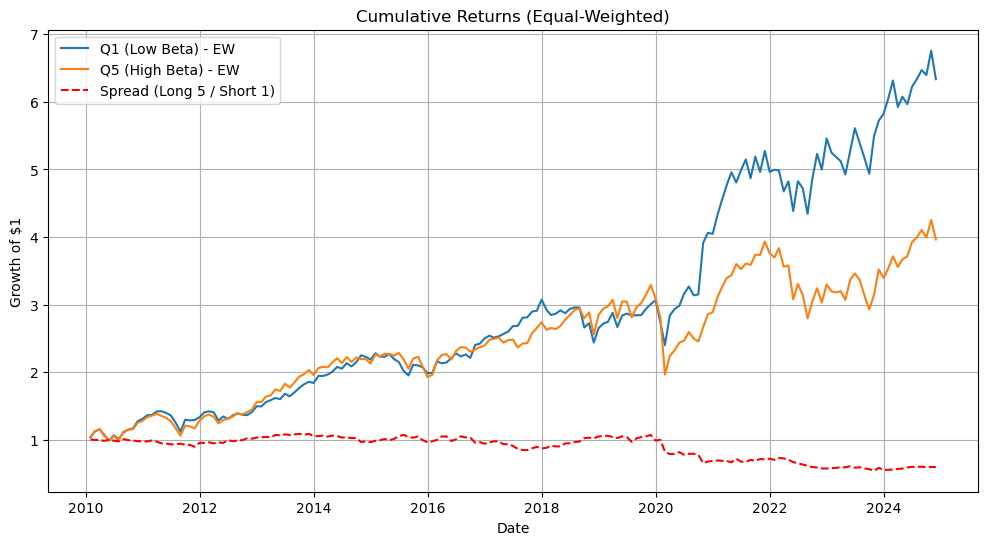


=== Equal-Weighted Alpha ===
Spread Alpha: -0.0023 (t=-0.95)
-> [EW] Spread Alpha is Negative (Consistent with Paper)


In [5]:
# Cell 3: Stage 1 - Equal-Weighted Analysis (수정됨)

import statsmodels.api as sm
import matplotlib.pyplot as plt

# 1. Equal-Weighted 수익률 계산 (단순 평균)
# monthly_ret 컬럼을 기준으로 평균을 냅니다.
port_stats_ew = merged_port.groupby(['ym', 'quintile'])['monthly_ret'].mean().reset_index()

# 피벗 테이블 생성
port_ret_pivot_ew = port_stats_ew.pivot(index='ym', columns='quintile', values='monthly_ret')

# Spread 계산 (Q5 - Q1)
port_ret_pivot_ew['Spread (5-1)'] = port_ret_pivot_ew[5] - port_ret_pivot_ew[1]

# 2. 시각화
cum_ret_ew = (1 + port_ret_pivot_ew).cumprod()
cum_ret_ew.index = cum_ret_ew.index.to_timestamp()

plt.figure(figsize=(12, 6))
plt.plot(cum_ret_ew.index, cum_ret_ew[1], label='Q1 (Low Beta) - EW')
plt.plot(cum_ret_ew.index, cum_ret_ew[5], label='Q5 (High Beta) - EW')
plt.plot(cum_ret_ew.index, cum_ret_ew['Spread (5-1)'], label='Spread (Long 5 / Short 1)', linestyle='--', color='red')
plt.title('Cumulative Returns (Equal-Weighted)')
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.legend()
plt.grid(True)
plt.show()

# 3. FF-3 Alpha 검증 (EW)
# 데이터 병합
# 인덱스를 리셋하여 'ym' 컬럼을 살린 후 병합
analysis_df_ew = pd.merge(port_ret_pivot_ew.reset_index(), ff3_monthly, on='ym', how='inner')

# 컬럼명 소문자 확인 (데이터에 따라 대문자일 수도 있으므로 보정)
if 'MKT_RF' in analysis_df_ew.columns:
    analysis_df_ew = analysis_df_ew.rename(columns={
        'MKT_RF': 'mkt_rf', 'SMB': 'smb', 'HML': 'hml', 'RF': 'rf'
    })

# --- [핵심 수정] 데이터 타입 강제 변환 ---
# 회귀분석에 필요한 컬럼들
reg_cols = ['mkt_rf', 'smb', 'hml', 'Spread (5-1)']

# 1) 숫자가 아닌 값(문자열 등)을 NaN으로 변환
for col in reg_cols:
    analysis_df_ew[col] = pd.to_numeric(analysis_df_ew[col], errors='coerce')

# 2) 결측치(NaN) 제거
analysis_df_ew.dropna(subset=reg_cols, inplace=True)

# 3) 데이터 타입을 명시적으로 float로 변환 (이게 없으면 에러 발생 가능)
analysis_df_ew[reg_cols] = analysis_df_ew[reg_cols].astype(float)

# 회귀분석 함수 (안전하게 수정됨)
def run_ff3(y_series, X_df):
    # X, y 모두 float 타입으로 확실하게 변환해서 넣음
    X = X_df[['mkt_rf', 'smb', 'hml']].astype(float)
    X = sm.add_constant(X)
    y = y_series.astype(float)
    return sm.OLS(y, X).fit()

# 결과 출력
print("\n=== Equal-Weighted Alpha ===")
try:
    model_spread = run_ff3(analysis_df_ew['Spread (5-1)'], analysis_df_ew)
    print(f"Spread Alpha: {model_spread.params['const']:.4f} (t={model_spread.tvalues['const']:.2f})")
    
    # (옵션) 해석 출력
    if model_spread.params['const'] < 0:
        print("-> [EW] Spread Alpha is Negative (Consistent with Paper)")
    else:
        print("-> [EW] Spread Alpha is Positive (Inconsistent)")
        
except Exception as e:
    print(f"Regression Failed: {e}")
    print("Check data columns:", analysis_df_ew.columns)

# Step 4: 2단계 - Idiosyncratic Volatility (IVOL) 구현

Calculating IVOL...


IVOL: 100%|██████████| 180/180 [00:50<00:00,  3.58it/s]


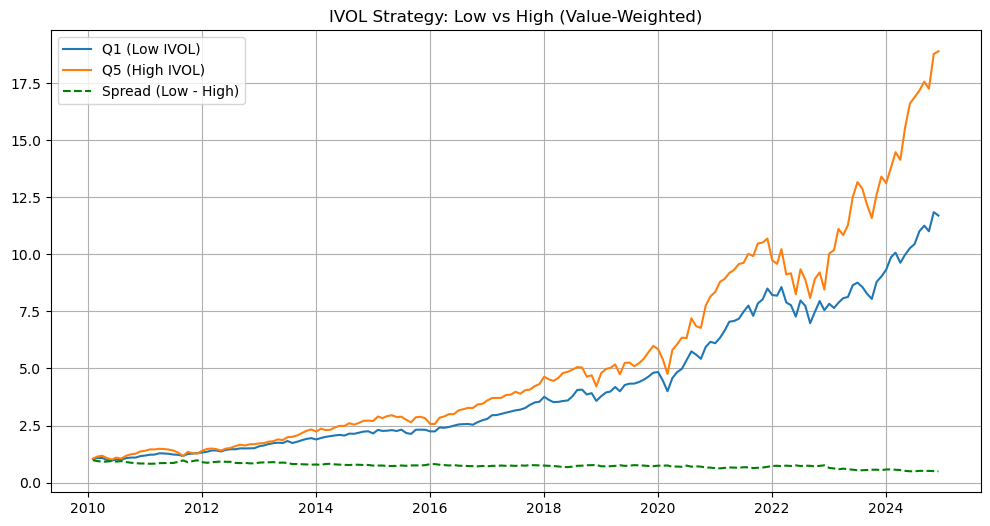


IVOL Spread Alpha: -0.0010 (t=-0.49)


In [6]:
# Cell 4: Stage 2 - IVOL Calculation & Analysis

ivol_results = []
print(f"Calculating IVOL...")

# IVOL 계산 (Rolling)
for current_date in tqdm(monthly_dates, desc="IVOL"):
    start_date = current_date - pd.tseries.offsets.MonthBegin(1)
    mask = (daily_panel['date'] >= start_date) & (daily_panel['date'] <= current_date)
    window_data = daily_panel.loc[mask]
    
    if len(window_data) < 17: continue

    for permno, group in window_data.groupby('permno'):
        df_reg = group[['excess_ret', 'mkt_rf', 'smb', 'hml']].dropna()
        if len(df_reg) < 17: continue
        
        # FF-3 잔차 표준편차 구하기
        try:
            model = sm.OLS(df_reg['excess_ret'], sm.add_constant(df_reg[['mkt_rf', 'smb', 'hml']])).fit()
            ivol_results.append({
                'date': current_date,
                'permno': permno,
                'ivol': model.resid.std()  # Idiosyncratic Volatility
            })
        except: continue

ivol_df = pd.DataFrame(ivol_results)

# 포트폴리오 구성 (IVOL 기준 5분위)
ivol_df['quintile'] = ivol_df.groupby('date')['ivol'].transform(
    lambda x: pd.qcut(x, 5, labels=[1, 2, 3, 4, 5])
)
ivol_df['ym'] = ivol_df['date'].dt.to_period('M')
ivol_df['target_ym'] = ivol_df['ym'] + 1

# 수익률 매칭 & 성과 분석 (Value-Weighted)
merged_ivol = pd.merge(
    ivol_df[['target_ym', 'permno', 'quintile']],
    stock_monthly[['ym', 'permno', 'monthly_ret', 'mktcap']],
    left_on=['target_ym', 'permno'],
    right_on=['ym', 'permno'],
    how='inner'
)

# VW 수익률 계산 함수 (재사용)
def calc_vw(x):
    if x['mktcap'].sum() == 0: return 0
    return (x['monthly_ret'] * x['mktcap']).sum() / x['mktcap'].sum()

port_stats_ivol = merged_ivol.groupby(['ym', 'quintile']).apply(
    lambda x: pd.Series({'ret_vw': calc_vw(x)})
).reset_index()

# Spread (1-5: Low IVOL - High IVOL)
pivot_ivol = port_stats_ivol.pivot(index='ym', columns='quintile', values='ret_vw')
pivot_ivol['Spread (1-5)'] = pivot_ivol[1] - pivot_ivol[5]

# 시각화
cum_ivol = (1 + pivot_ivol).cumprod()
cum_ivol.index = cum_ivol.index.to_timestamp()

plt.figure(figsize=(12, 6))
plt.plot(cum_ivol.index, cum_ivol[1], label='Q1 (Low IVOL)')
plt.plot(cum_ivol.index, cum_ivol[5], label='Q5 (High IVOL)')
plt.plot(cum_ivol.index, cum_ivol['Spread (1-5)'], label='Spread (Low - High)', linestyle='--', color='green')
plt.title('IVOL Strategy: Low vs High (Value-Weighted)')
plt.legend()
plt.grid(True)
plt.show()

# Alpha 확인
analysis_ivol = pd.merge(pivot_ivol.reset_index(), ff3_monthly, on='ym', how='inner')
for c in num_cols[:4]: analysis_ivol[c] = pd.to_numeric(analysis_ivol[c], errors='coerce')
analysis_ivol.dropna(inplace=True)

model_ivol = run_ff3(analysis_ivol['Spread (1-5)'], analysis_ivol)
print(f"\nIVOL Spread Alpha: {model_ivol.params['const']:.4f} (t={model_ivol.tvalues['const']:.2f})")